# Pune Property Price Analysis 🏠🏘️

## 04. Price Based Recommendation Notebook
To develop a smart property recommendation system that suggests suitable properties based on user preferences such as budget, locality, area, and configuration.

# 1. Importing the Libraries

In [55]:
# Import libraries

import pandas as pd
import numpy as np
import joblib
import json
import seaborn as sns
import matplotlib.pyplot as plt
import locale

# 2. Loading the Saved Models

In [56]:
from google.colab import drive
drive.mount('/content/drive')

# Loading Trained Unfurnished Models

unfurnished_model = joblib.load("/content/drive/MyDrive/ML_Projects/Pune_Property/Models/1_rf_unfurnished_final_production_model.pkl")

 # Loadinng Trained Furnished Model

furnished_model = joblib.load("/content/drive/MyDrive/ML_Projects/Pune_Property/Models/2_rf_furnished_full_production_pipeline.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Loading MAE Metadata

In [57]:
# MAE VALues

with open("/content/drive/MyDrive/ML_Projects/Pune_Property/Models/3_unfurnished_mae.json", "r") as f:
  unfurnished_mae = json.load(f)["mae"]

with open("/content/drive/MyDrive/ML_Projects/Pune_Property/Models/4_furnished_mae.json", "r") as f:
  furnished_mae = json.load(f)["mae"]

print("Unfurnished MAE: ", unfurnished_mae)
print("Furnished MAE: ", furnished_mae)

print("\nAfter Converting MAE to Original Values: \n")

print("Unfurnished: ", np.exp(unfurnished_mae))
print("Furnished: ", np.exp(furnished_mae))

Unfurnished MAE:  0.2605488334981219
Furnished MAE:  0.25704162279148085

After Converting MAE to Original Values: 

Unfurnished:  1.2976420807072742
Furnished:  1.293098948027128


#4. Loading the cleaned Dataset

In [58]:
df = pd.read_csv("/content/pune_property_cleaned_Nan_filled.csv")
#df = pd.read_csv("/content/drive/MyDrive/ML_Projects/Pune_Property/Cleaned_Data/cleaned_pune_property_ds.csv")
df.head()

,balconies,bathroom,facing,locality,opensides,possesiondate,price,totalfloor,no. of additional rooms,studyroom,...,Wardrobe,TV,Refrigerator,Sofa,Washing Machine,Wifi,Microwave,Dining Table,Gas connection,BED
0,2.0,3.0,West,Deccan Gymkhana,2.0,NaN,27000000,6.0,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,No
1,NaN,2.0,NorthEast,Kharadi,NaN,NaN,7610050,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
2,NaN,1.0,NorthEast,Sus,NaN,NaN,4100000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
3,NaN,2.0,NorthEast,Bavdhan,NaN,NaN,5736000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
4,1.0,3.0,West,Deccan Gymkhana,2.0,NaN,29002000,9.0,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No


# 5. Dataset Structure

In [59]:
print(f"Total Rows are {df.shape[0]} and Columns are {df.shape[1]}")

Total Rows are 21912 and Columns are 74


# 6. Similated User Inputs

In [60]:
property_type = input("Enter the Property Type (Unfurnished/Furnished): ")

Enter the Property Type (Unfurnished/Furnished): Furnished


# 7. Furnished and Unfurnished Condition

In [73]:
# ------------- FURNISHED ---------------------

if property_type.lower() == "furnished":

  user = {
        "balconies" : 3.0,
        "bathroom" : 4.0,
        "house type" : "New",
        "no. of additional rooms" : 0.0,
        "total area" : 1600.0,
        "total rooms" : 6.0,
        "Car Parking" :"Yes",
        "Power Backup": "Yes",
        "AC": "Yes",
        "TV" : "Yes",
        "Refrigerator" : "Yes",
        "Sofa": "Yes",
        "Wardrobe": "Yes",
        "Washing Machine": "Yes",
        "Gas connection": "Yes",
        "BED": "No"
  }
  user_df = pd.DataFrame([user])

  # Predicting the price
  predicted_price = furnished_model.predict(user_df)[0]

  # mae
  mae = furnished_mae

# ---------- UNFURNISHED ----------

elif property_type.lower() == "unfurnished":

  user = {
      "balconies" : 1.0,
        "bathroom" : 2.0,
        "house type" : "New",
        "no. of additional rooms" : 1.0,
        "total area" : 1500.0,
        "total rooms" : 3.0,
        "Car Parking" : "Yes",
        "Power Backup" : "Yes"
  }

  user_df = pd.DataFrame([user])

  # Price Prediction
  predicted_price = unfurnished_model.predict(user_df)[0]

  # Mae
  mae = unfurnished_mae


# 8. Conversion of Amount to Indian Format

In [74]:
def format_indian(number):
    s = str(int(number))
    if len(s) <= 3:
        return s

    last_three = s[-3:]
    remaining = s[:-3]

    formatted_remaining = ",".join(
        [remaining[max(i-2, 0):i] for i in range(len(remaining), 0, -2)][::-1]
    )

    return f"{formatted_remaining},{last_three}"

# 9. Creating the Price Range Using the MAE

In [75]:
lower_range = predicted_price - mae
upper_range = predicted_price + mae

pred_price = round(np.expm1(predicted_price))
lower_price = round(np.expm1(lower_range))
upper_price = round(np.expm1(upper_range))

# 10. Printing the Predicted Flat Price

In [76]:
print(f"✨ Estimated Flat Price: ₹ {format_indian(pred_price)}")
print(f"💰 Budget Range: ₹ {format_indian(lower_price)} - ₹ {format_indian(upper_price)}")

✨ Estimated Flat Price: ₹ 1,91,59,409
💰 Budget Range: ₹ 1,48,16,661 - ₹ 2,47,75,011


# 11. Recommended Flats

In [78]:
recommended_flates = df[(df["price"]>= lower_price) & (df["price"] <= upper_price)]
recommended_flates

,balconies,bathroom,facing,locality,opensides,possesiondate,price,totalfloor,no. of additional rooms,studyroom,...,Wardrobe,TV,Refrigerator,Sofa,Washing Machine,Wifi,Microwave,Dining Table,Gas connection,BED
8,2.0,3.0,West,Law collage Road,2.0,NaN,24000000,6.0,3.0,Yes,...,Yes,No,Yes,Yes,Yes,No,No,Yes,Yes,No
12,1.0,2.0,East,Deccan Gymkhana,2.0,NaN,20300000,5.0,2.0,Yes,...,No,No,No,No,No,No,No,No,No,No
13,3.0,5.0,West,Bhukum,3.0,01-03-2018,18000000,12.0,3.0,Yes,...,No,No,No,No,No,No,No,No,Yes,No
24,NaN,NaN,NaN,Hadapsar,NaN,NaN,23100000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
29,NaN,NaN,NaN,Hadapsar,NaN,NaN,20000000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21878,NaN,3.0,NorthEast,Koregaon Park,NaN,NaN,16000000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
21894,NaN,4.0,East,Viman Nagar,NaN,NaN,16000000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No
21896,2.0,3.0,NorthEast,Koregaon Park,NaN,NaN,23000000,12.0,1.0,Yes,...,Yes,No,Yes,Yes,No,No,No,No,No,Yes
21905,NaN,4.0,NaN,Kharadi,NaN,NaN,15000000,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No


# 12. Area Matching (with Tolearance)

In [79]:
area_tolearance = 150

recommended_flates = recommended_flates[abs(recommended_flates["total area"] - user["total area"]) <= area_tolearance]
recommended_flates["total area"]

,total area
8,1650.0
61,1500.0
117,1470.0
133,1645.0
135,1700.0
...,...
21620,1700.0
21621,1680.0
21634,1450.0
21704,1690.0


# 13. Final Output


In [80]:
if recommended_flates.empty:
  print("Currently No Matching Flats available in Pune")

else:
  print("Matching Flats Found Based on Price Range and Total Area: ")

  display(
      recommended_flates[["locality", "total area", "price"]]
      .sort_values(by = "price")
      .head(10)

  )

Matching Flats Found Based on Price Range and Total Area: 


,locality,total area,price
6163,Kalyani Nagar,1500.0,14900000
17348,Viman Nagar,1620.0,14900000
21533,Koregaon Park,1750.0,15000000
21634,Koregaon Park,1450.0,15000000
2179,Koregaon Park,1489.0,15000000
19626,Kalyani Nagar,1475.0,15000000
20237,Viman Nagar,1650.0,15000000
19983,Kalyani Nagar,1735.0,15000000
15407,Viman Nagar,1650.0,15000000
14823,Mundhwa,1705.0,15000000


# 14. Total Flats Available in Each Locality

In [89]:
lt = recommended_flates.groupby("locality").size().sort_values(ascending=False)
lt

,0
locality,
Kalyani Nagar,196
Viman Nagar,168
Koregaon Park,127
Wadgaon Sheri,27
Boat Club Road,23
Bund Garden,20
Mundhwa,17
Shastri Nagar,11
Aundh,10


/tmp/ipython-input-1222503445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = lt.values, y =  lt.index, palette="flare")


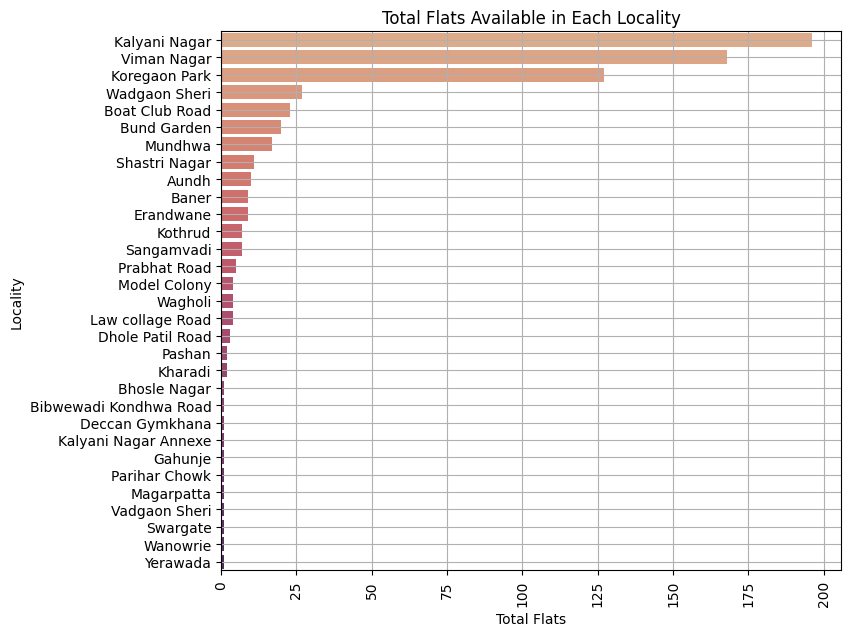

In [92]:
plt.figure(figsize=(8,7))
sns.barplot(x = lt.values, y =  lt.index, palette="flare")
plt.xticks(rotation = 90)
plt.xlabel("Total Flats")
plt.ylabel("Locality")
plt.title("Total Flats Available in Each Locality")
plt.grid(True)
plt.show()

In [82]:
s = str(1479569)

print(s[-3:])
print(s[:-3])

569
1479
